# 🚗 DoorDash Delivery Prediction
## Notebook 02 — Data Cleaning

**Goal:** Fix nulls, wrong data types, outliers, and duplicates. Save clean data to `data/processed/`.

**Author:** Divyargarg

---

In [1]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── CELL 2: Load Raw Data ─────────────────────────────────────────────
df = pd.read_csv('../data/raw/historical_data.csv')

print(f'✅ Raw data loaded!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Raw data loaded!
📊 Shape: 197428 rows × 16 columns


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [3]:
# ── CELL 3: Snapshot Before Cleaning ─────────────────────────────────
# Always record state before making changes
rows_before = len(df)
cols_before = len(df.columns)
nulls_before = df.isnull().sum().sum()

print(f'📊 BEFORE CLEANING:')
print(f'   Rows    : {rows_before}')
print(f'   Columns : {cols_before}')
print(f'   Nulls   : {nulls_before}')

📊 BEFORE CLEANING:
   Rows    : 197428
   Columns : 16
   Nulls   : 56061


In [4]:
# ── CELL 4: Remove Duplicate Rows ────────────────────────────────────
dupes = df.duplicated().sum()
print(f'🔁 Duplicate rows found: {dupes}')

df = df.drop_duplicates()
print(f'✅ Duplicates removed. Rows remaining: {len(df)}')

🔁 Duplicate rows found: 0
✅ Duplicates removed. Rows remaining: 197428


In [5]:
# ── CELL 5: Inspect & Fix Data Types ─────────────────────────────────
print('📋 Current Data Types:')
print(df.dtypes)

# Fix timestamp columns if they exist — adjust column names to match yours
# Example: if 'created_at' is a datetime stored as string, convert it
timestamp_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
print(f'\n🕐 Potential timestamp columns: {timestamp_cols}')

for col in timestamp_cols:
    try:
        df[col] = pd.to_datetime(df[col])
        print(f'  ✅ Converted {col} to datetime')
    except Exception as e:
        print(f'  ⚠️  Could not convert {col}: {e}')

📋 Current Data Types:
market_id                                       float64
created_at                                          str
actual_delivery_time                                str
store_id                                          int64
store_primary_category                              str
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_order_place_duration                    int64
estimated_store_to_consumer_driving_duration    float64
dtype: object

🕐 Potential timestamp columns: ['actual_delivery_time']
  ✅ Convert

In [6]:
# ── CELL 6: Handle Missing Values ────────────────────────────────────
print('📊 Missing Values Summary:')
null_df = pd.DataFrame({
    'nulls': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df = null_df[null_df['nulls'] > 0].sort_values('pct_missing', ascending=False)
print(null_df)

# Strategy per column — adjust based on your EDA findings:
# - Drop columns with > 50% missing
# - Impute numeric columns with median (safer than mean for skewed data)
# - Impute categorical columns with mode

# Drop columns with too many nulls
threshold = 0.5
cols_to_drop = null_df[null_df['pct_missing'] > threshold * 100].index.tolist()
if cols_to_drop:
    print(f'\n🗑️  Dropping columns with >50% nulls: {cols_to_drop}')
    df = df.drop(columns=cols_to_drop)
else:
    print('\n✅ No columns exceed 50% missing threshold')

📊 Missing Values Summary:
                                              nulls  pct_missing
total_busy_dashers                            16262         8.24
total_outstanding_orders                      16262         8.24
total_onshift_dashers                         16262         8.24
store_primary_category                         4760         2.41
market_id                                       987         0.50
order_protocol                                  995         0.50
estimated_store_to_consumer_driving_duration    526         0.27
actual_delivery_time                              7         0.00

✅ No columns exceed 50% missing threshold


In [7]:
# ── CELL 7: Impute Remaining Nulls ───────────────────────────────────
# Numeric → median imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  ✅ {col}: filled {df[col].isnull().sum()} nulls with median ({median_val:.2f})')

# Categorical → mode imputation
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'  ✅ {col}: filled nulls with mode ("{mode_val}")')

print(f'\n📊 Total nulls remaining: {df.isnull().sum().sum()}')

  ✅ market_id: filled 0 nulls with median (3.00)
  ✅ order_protocol: filled 0 nulls with median (3.00)
  ✅ total_onshift_dashers: filled 0 nulls with median (37.00)
  ✅ total_busy_dashers: filled 0 nulls with median (34.00)
  ✅ total_outstanding_orders: filled 0 nulls with median (41.00)
  ✅ estimated_store_to_consumer_driving_duration: filled 0 nulls with median (544.00)
  ✅ store_primary_category: filled nulls with mode ("american")

📊 Total nulls remaining: 7


C:\Users\divya\AppData\Local\Temp\ipykernel_24836\3377112981.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [8]:
# ── CELL 8: Detect & Handle Outliers (IQR Method) ────────────────────
# IQR = Interquartile Range — values beyond 1.5x IQR are outliers

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (outliers / len(df)) * 100
    outlier_summary.append({'column': col, 'outliers': outliers, 'pct': pct, 'lower': lower, 'upper': upper})

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)
print('📊 Outlier Summary (IQR Method):')
print(outlier_df.to_string(index=False))

📊 Outlier Summary (IQR Method):
                                      column  outliers      pct   lower   upper
                                 total_items      9588 4.856454    -1.0     7.0
                                    subtotal      9054 4.585976 -1592.5  6387.5
                    total_outstanding_orders      8507 4.308913   -72.5   171.5
                              max_item_price      7729 3.914845   -92.5  2287.5
                          num_distinct_items      5919 2.998055    -2.0     6.0
                       total_onshift_dashers      4661 2.360861   -45.5   126.5
                              min_item_price      4600 2.329963  -676.0  1924.0
                          total_busy_dashers      2878 1.457747   -46.0   122.0
estimated_store_to_consumer_driving_duration       378 0.191462   -95.5  1180.5
              estimated_order_place_duration        28 0.014182   -41.5   738.5
                                    store_id         0 0.000000 -3733.5 10718.5
        

In [9]:
# ── CELL 9: Cap Outliers (Winsorizing) ───────────────────────────────
# Instead of removing rows, we cap extreme values at the IQR boundaries
# This keeps the data but removes extreme distortion

for _, row in outlier_df.iterrows():
    col = row['column']
    if row['pct'] > 1:  # Only cap if more than 1% are outliers
        df[col] = df[col].clip(lower=row['lower'], upper=row['upper'])
        print(f'  ✅ Capped outliers in: {col} (range: {row["lower"]:.2f} → {row["upper"]:.2f})')

print('\n✅ Outlier capping complete!')

  ✅ Capped outliers in: total_items (range: -1.00 → 7.00)
  ✅ Capped outliers in: subtotal (range: -1592.50 → 6387.50)
  ✅ Capped outliers in: total_outstanding_orders (range: -72.50 → 171.50)
  ✅ Capped outliers in: max_item_price (range: -92.50 → 2287.50)
  ✅ Capped outliers in: num_distinct_items (range: -2.00 → 6.00)
  ✅ Capped outliers in: total_onshift_dashers (range: -45.50 → 126.50)
  ✅ Capped outliers in: min_item_price (range: -676.00 → 1924.00)
  ✅ Capped outliers in: total_busy_dashers (range: -46.00 → 122.00)

✅ Outlier capping complete!


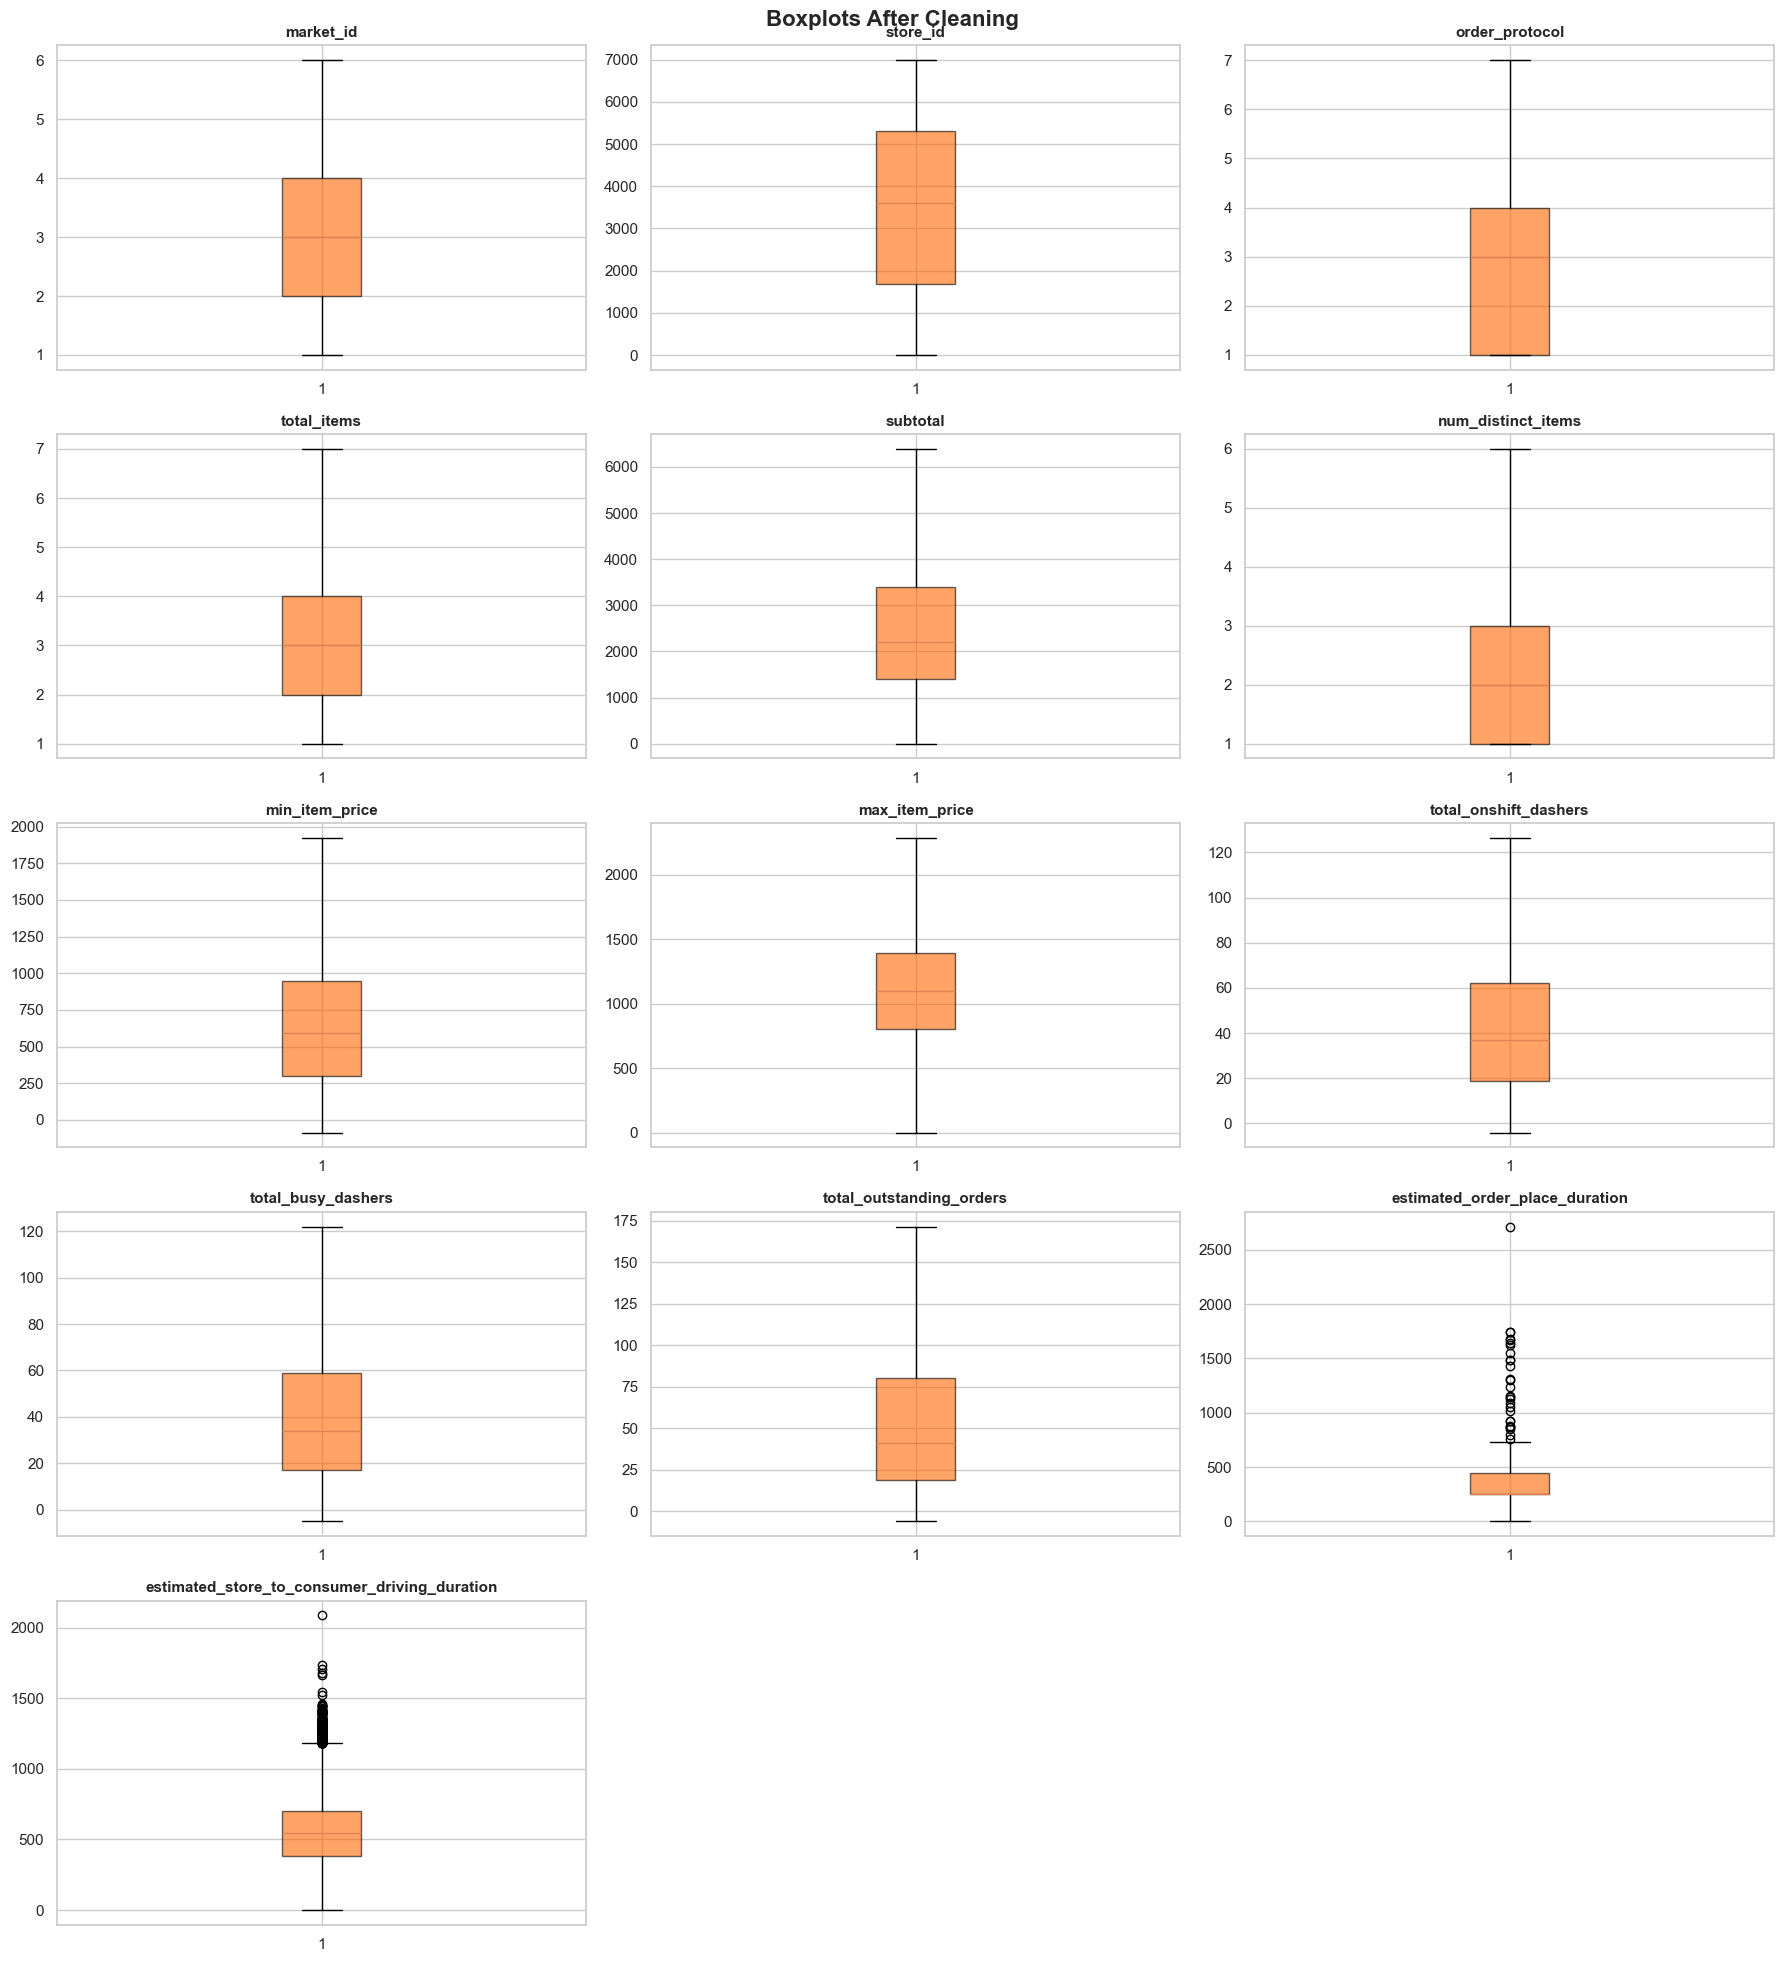

✅ Saved to outputs/figures/


In [10]:
# ── CELL 10: Boxplots After Cleaning ─────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#FF6600', alpha=0.6))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots After Cleaning', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_boxplots_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to outputs/figures/')

In [11]:
# ── CELL 11: Cleaning Summary ─────────────────────────────────────────
rows_after = len(df)
cols_after = len(df.columns)
nulls_after = df.isnull().sum().sum()

print('📊 CLEANING SUMMARY')
print(f"{'Metric':<20} {'Before':<15} {'After'}")
print('-' * 45)
print(f"{'Rows':<20} {rows_before:<15} {rows_after}")
print(f"{'Columns':<20} {cols_before:<15} {cols_after}")
print(f"{'Nulls':<20} {nulls_before:<15} {nulls_after}")

📊 CLEANING SUMMARY
Metric               Before          After
---------------------------------------------
Rows                 197428          197428
Columns              16              16
Nulls                56061           7


In [12]:
# ── CELL 12: Save Clean Data ──────────────────────────────────────────
df.to_csv('../data/processed/cleaned_data.csv', index=False)
print('✅ Clean data saved to data/processed/cleaned_data.csv')
print(f'📊 Final shape: {df.shape}')

✅ Clean data saved to data/processed/cleaned_data.csv
📊 Final shape: (197428, 16)
